# Code trying a set of beta choices for duration models before large simulations

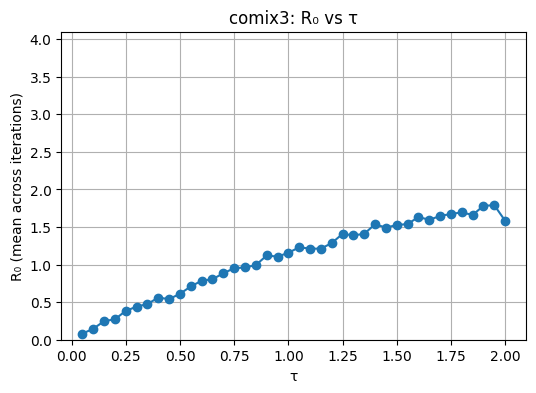

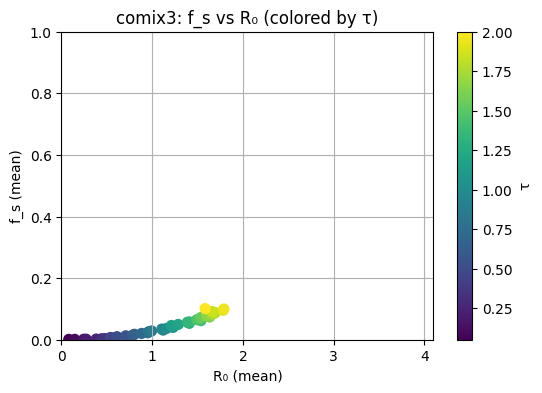

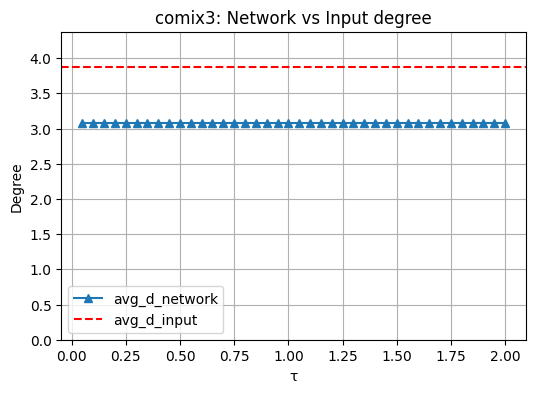

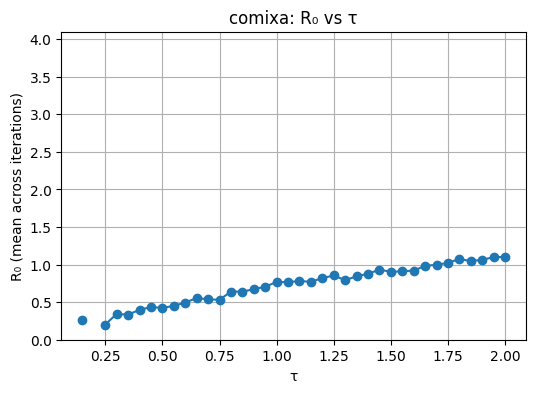

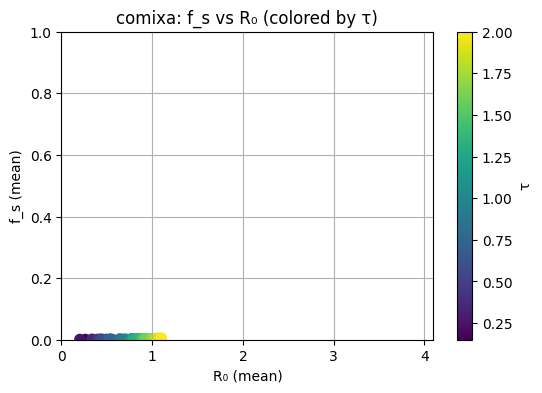

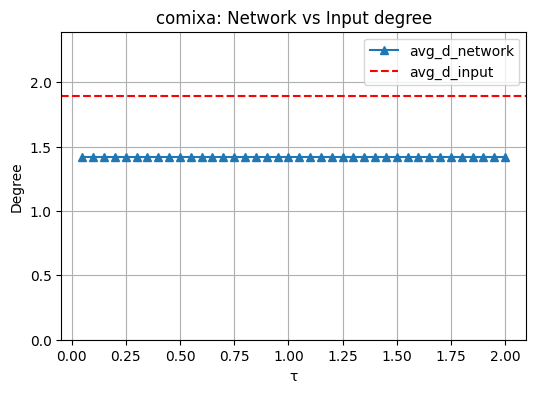

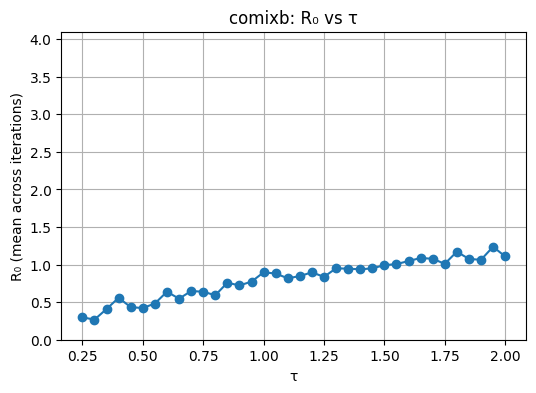

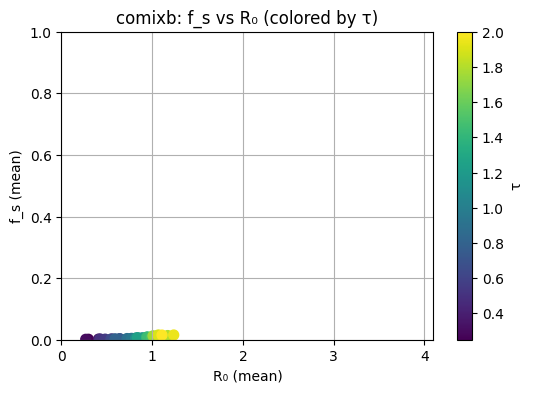

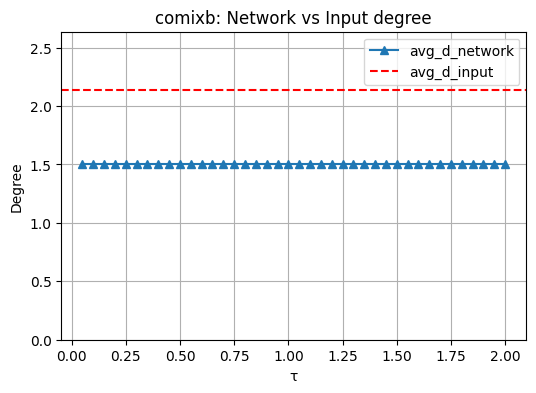

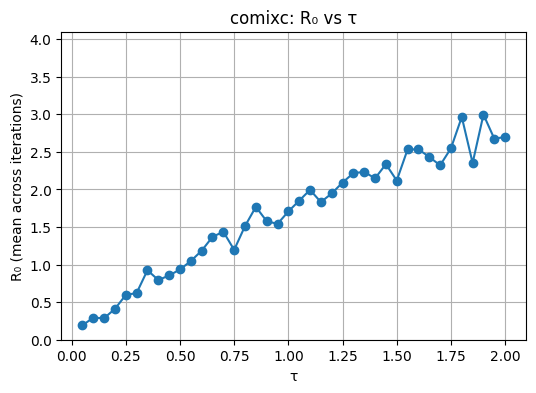

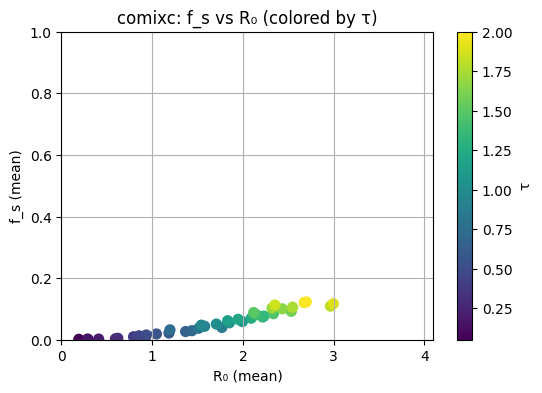

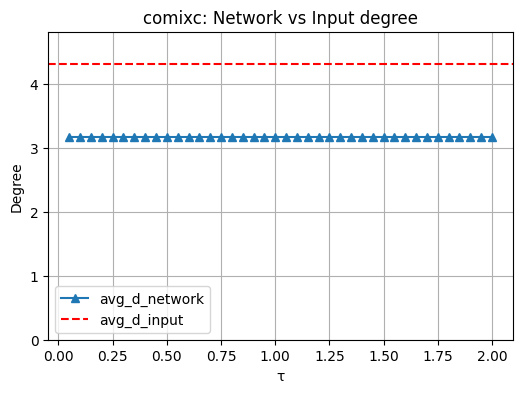

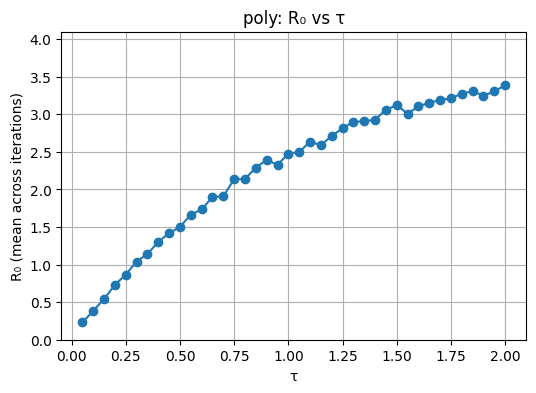

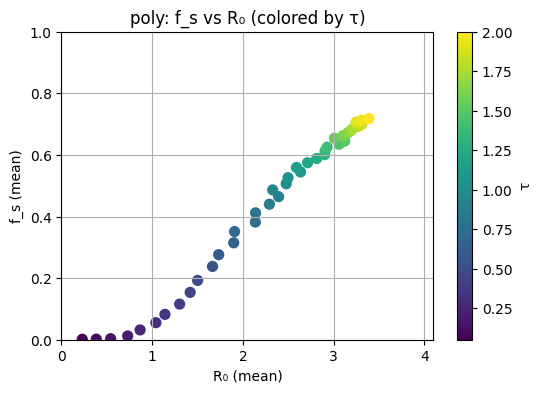

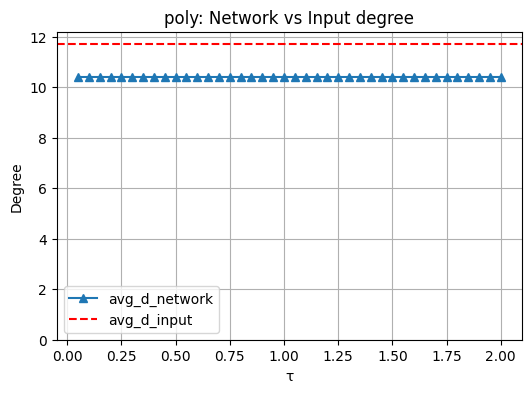

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import json

datas = ['comix3','comixa','comixb','comixc','poly']

for data in datas:
    with open(f'sims/{data}_0.json', 'r') as f:
        res = json.load(f)

    # Extract from your dictionary
    taus = np.array(res["taus"])
    r0 = np.array(res["r0"])           # shape (len(taus), iterations)
    fs = np.array(res["fs"])           # shape (len(taus), iterations)
    avg_d_network = np.array(res["avg_d_network"])
    avg_d_input = res["avg_d_input"]/n   # scalar

    # Average across iterations
    r0_mean = [np.mean([b for b in a if b>0]) for a in r0]
    fs_mean = [np.mean([b for b in a if b>0]) for a in fs]

    # 1) R0 vs taus
    plt.figure(figsize=(6,4))
    plt.plot(taus, r0_mean, marker='o')
    plt.xlabel("τ")
    plt.ylabel("R₀ (mean across iterations)")
    plt.title(f"{data}: R₀ vs τ")
    plt.ylim(0, 4.1)
    plt.grid(True)
    plt.show()

    # # 2) fs vs taus
    # plt.figure(figsize=(6,4))
    # plt.plot(taus, fs_mean, marker='s', color='orange')
    # plt.xlabel("τ")
    # plt.ylabel("f_s (mean)")
    # plt.title(f"{data}: f_s vs τ")
    # plt.ylim(0, 1)
    # plt.grid(True)
    # plt.show()

    # 3) fs vs R0
    plt.figure(figsize=(6,4))
    plt.scatter(r0_mean, fs_mean, c=taus, cmap="viridis", s=50)
    plt.colorbar(label="τ")
    plt.xlabel("R₀ (mean)")
    plt.ylabel("f_s (mean)")
    plt.title(f"{data}: f_s vs R₀ (colored by τ)")
    plt.xlim(0, 4.1)
    plt.ylim(0, 1)
    plt.grid(True)
    plt.show()

    # 4) avg_d_network vs avg_d_input
    plt.figure(figsize=(6,4))
    plt.plot(taus, avg_d_network, marker='^', label="avg_d_network")
    plt.axhline(y=avg_d_input, color='red', linestyle='--', label="avg_d_input")
    plt.xlabel("τ")
    plt.ylabel("Degree")
    plt.title(f"{data}: Network vs Input degree")
    plt.ylim(0, max(max(avg_d_network), avg_d_input) + .5)
    plt.legend()
    plt.grid(True)
    plt.show()
